In [2]:
import os
import sys
# CaLRepo = os.environ.get("CaLRepo")
CaLRepo = '/home/zyq0416/workspace/CaL'
# print(CaLRepo)
sys.path.append(f"{CaLRepo}/utilities/")
import math
import numpy as np
from pyCostEstimator import Cost_Estimator
import matplotlib.pyplot as plt
## construct cost indictor
construct_labour_cost_indictor=0.25
engineering_project_cost_indictor=0.175
TASC_multiplier=1.13
piping_integration_cost_indictor=0.05
#单次储能时间8小时
Single_run_time=8*3600
#年循环次数（储能2560小时，释能2560小时，年运行时间5120小时
Annual_cycle_count = 320
#循环极限次数
Limit_cycle_number = 50
#安全存储比例

#氢氧化钙价格RMB/t
caoh2_unit_price=1500
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol

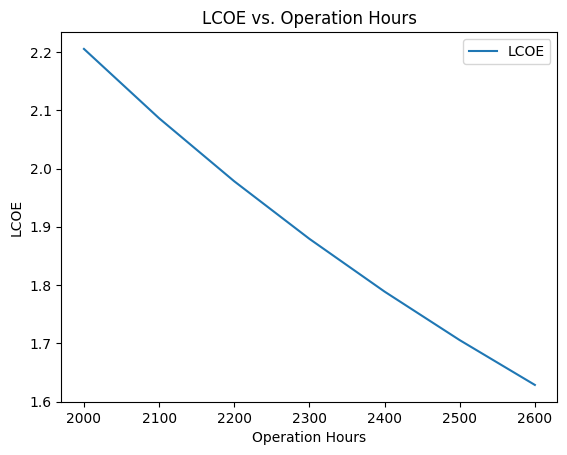

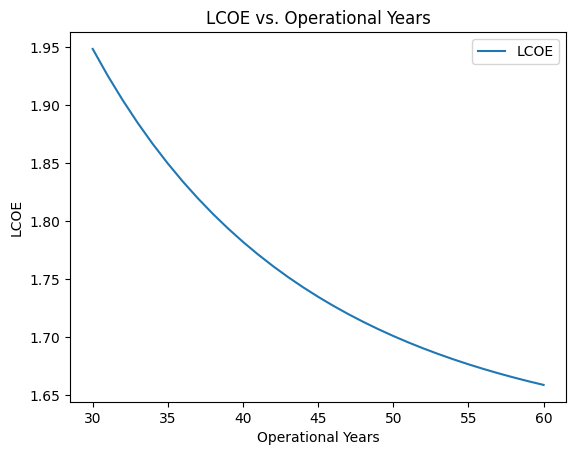

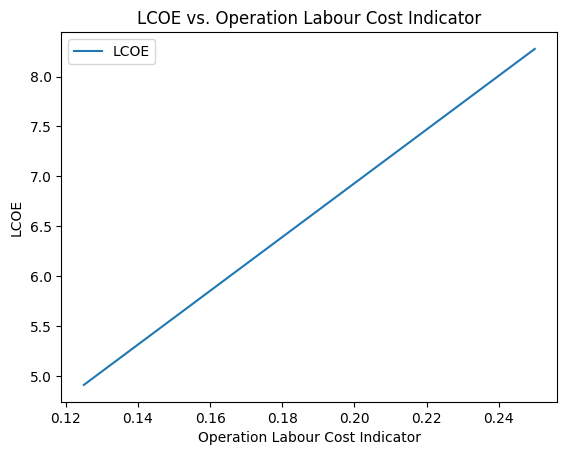

In [2]:
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["industrial_waste_heat_t"] =300 #℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20   #环境温度
parameters["p_amb"] = 101325   #环境压力

parameters["p_bray_L"] = 7.5e6
parameters["Store_electrical_power"] = 50e6  # 机组容量
parameters["p_water_supply_in"] = 2e5 
parameters["water_pressure_drop_rate"] = 100 #100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  #氧化钙转化率
parameters["cao_purity"] = 0.98 #氢氧化钙含量
parameters["dehydrator_eff"] = 0.95   #脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3/100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95   #水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs={}
inputs["p_bray_H"] = 18716228#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12481150 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"]=440
inputs["T_X"] = 1

# 经济输入的基础值
economic_inputs_base = {
    "elec_price": 0,  # 元/千瓦时
    "elec_price_h": 1.2784,
    "hot_price_h": 0.1542,
    "operation_hours": 2560,  # hours
    "discount_ratio": 6/100,  # 8%
    "operational_years": 60,
    "operation_labour_cost_indictor": 0.025/2*(2/3)/2,  # 劳动力比例
    "maintain_cost_indictor": 0.025/2/2  # 维护比例
}
# 绘制图1：operation_hours 从 2000 到 2600 小时，y 的变化
operation_hours_values = range(2000, 2601, 100)
LCOE_values_hours = []
for hours in operation_hours_values:
    economic_inputs = economic_inputs_base.copy()
    economic_inputs["operation_hours"] = hours
    cost = Cost_Estimator(parameters)
    results = cost.solve(inputs, economic_inputs)
    LCOE_values_hours.append(results["LCOE"])
 
plt.figure(1)
plt.plot(operation_hours_values, LCOE_values_hours, label='LCOE')
plt.xlabel('Operation Hours')
plt.ylabel('LCOE')
plt.title('LCOE vs. Operation Hours')
plt.legend()
 
# 绘制图2：operational_years 从 30 到 60，y 的变化
operational_years_values = range(30, 61)
LCOE_values_years = []
for years in operational_years_values:
    economic_inputs = economic_inputs_base.copy()
    economic_inputs["operational_years"] = years
    cost = Cost_Estimator(parameters)
    results = cost.solve(inputs, economic_inputs)
    LCOE_values_years.append(results["LCOE"])
 
plt.figure(2)
plt.plot(operational_years_values, LCOE_values_years, label='LCOE')
plt.xlabel('Operational Years')
plt.ylabel('LCOE')
plt.title('LCOE vs. Operational Years')
plt.legend()
 
# 绘制图3：operation_labour_cost_indictor 从 0.0125 到 0.025，y 的变化
operation_labour_cost_indictor_values = [i/80 for i in range(10, 21)]
LCOE_values_labour = []
for indicator in operation_labour_cost_indictor_values:
    economic_inputs = economic_inputs_base.copy()
    economic_inputs["operation_labour_cost_indictor"] = indicator
    cost = Cost_Estimator(parameters)
    results = cost.solve(inputs, economic_inputs)
    LCOE_values_labour.append(results["LCOE"])
 
plt.figure(3)
plt.plot(operation_labour_cost_indictor_values, LCOE_values_labour, label='LCOE')
plt.xlabel('Operation Labour Cost Indicator')
plt.ylabel('LCOE')
plt.title('LCOE vs. Operation Labour Cost Indicator')
plt.legend()
 
# 显示所有图表
plt.show()



/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25805 (\N{CJK UNIFIED IDEOGRAPH-64CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-657

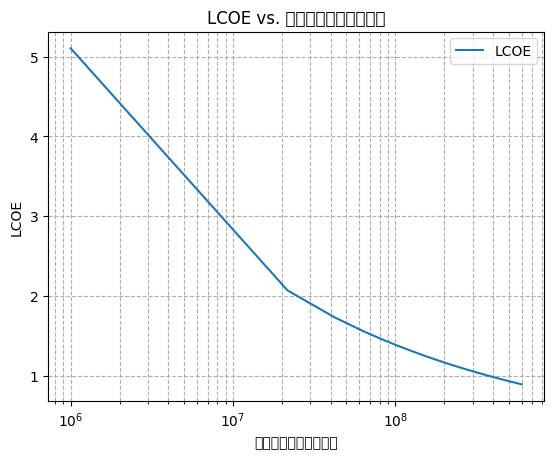

/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zyq0416/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EF

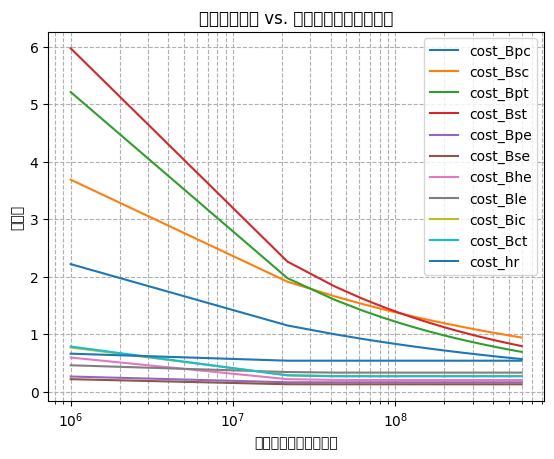

In [3]:
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["industrial_waste_heat_t"] =300 #℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20   #环境温度
parameters["p_amb"] = 101325   #环境压力

parameters["p_bray_L"] = 7.5e6
parameters["Store_electrical_power"] = 50e6  # 机组容量
parameters["p_water_supply_in"] = 2e5 
parameters["water_pressure_drop_rate"] = 100 #100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  #氧化钙转化率
parameters["cao_purity"] = 0.98 #氢氧化钙含量
parameters["dehydrator_eff"] = 0.95   #脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3/100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95   #水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs={}
inputs["p_bray_H"] = 18716228#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12481150 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"]=440
inputs["T_X"] = 1

# 经济输入的基础值
economic_inputs_base = {
    "elec_price": 0,  # 元/千瓦时
    "elec_price_h": 1.2784,
    "hot_price_h": 0.1542,
    "operation_hours": 2560,  # hours
    "discount_ratio": 6/100,  # 8%
    "operational_years": 60,
    "operation_labour_cost_indictor": 0.025/2*(2/3)/2,  # 劳动力比例
    "maintain_cost_indictor": 0.025/2/2  # 维护比例
}
operation_hours_values = np.linspace(1e6, 600e6, 30)
LCOE_values_hours = []
cost_Bpc_values = []
cost_Bsc_values = []
cost_Bpt_values = []
cost_Bst_values = []
cost_Bpe_values = []
cost_Bse_values = []
cost_Bhe_values = []
cost_Ble_values = []
cost_Bic_values = []
cost_Bct_values = []
cost_Bhr_values = []
 
# 遍历操作小时数列表
for hours in operation_hours_values:
    # 复制基础经济输入
    economic_inputs = economic_inputs_base.copy()
    # 设置与操作小时数相关的参数（这里假设 Store_electrical_power 代表操作小时数或与之相关）
    parameters["Store_electrical_power"] = hours
    
    # 创建成本估算器实例并求解
    cost_estimator = Cost_Estimator(parameters)
    results = cost_estimator.solve(inputs, economic_inputs)
    
    # 存储 LCOE 结果
    LCOE_values_hours.append(results["LCOE"])
    
    # 计算并存储每个成本项除以小时数的结果
    cost_Bpc_values.append(results["construction"]["equipment"]["cost_Bpc"] / hours)  # 使用 get 方法以防键不存在
    cost_Bsc_values.append(results["construction"]["equipment"]["cost_Bsc"] / hours)
    cost_Bpt_values.append(results["construction"]["equipment"]["cost_Bpt"] / hours)
    cost_Bst_values.append(results["construction"]["equipment"]["cost_Bst"] / hours)
    cost_Bpe_values.append(results["construction"]["equipment"]["cost_Bpe"] / hours)
    cost_Bse_values.append(results["construction"]["equipment"]["cost_Bse"] / hours)
    cost_Bhe_values.append(results["construction"]["equipment"]["cost_Bhe"] / hours)
    cost_Ble_values.append(results["construction"]["equipment"]["cost_Ble"] / hours)
    cost_Bic_values.append(results["construction"]["equipment"]["cost_Bic"] / hours)
    cost_Bct_values.append(results["construction"]["equipment"]["cost_Bct"] / hours)
    cost_Bhr_values.append(results["construction"]["equipment"]["cost_Bhr"] / hours)
 
# 绘制第一个图：LCOE vs. 操作小时数
plt.figure(1)
plt.plot(operation_hours_values, LCOE_values_hours, label='LCOE')
plt.xlabel('操作小时数或相关指标')
plt.ylabel('LCOE')
plt.title('LCOE vs. 操作小时数或相关指标')
plt.legend()
plt.xscale('log')  # 如果范围很大，使用对数刻度
plt.grid(True, which="both", ls="--")
 
# 绘制第二个图：各个成本项 vs. 操作小时数
plt.figure(2)
plt.plot(operation_hours_values, cost_Bpc_values, label='cost_Bpc')
plt.plot(operation_hours_values, cost_Bsc_values, label='cost_Bsc')
plt.plot(operation_hours_values, cost_Bpt_values, label='cost_Bpt')
plt.plot(operation_hours_values, cost_Bst_values, label='cost_Bst')
plt.plot(operation_hours_values, cost_Bpe_values, label='cost_Bpe')
plt.plot(operation_hours_values, cost_Bse_values, label='cost_Bse')
plt.plot(operation_hours_values, cost_Bhe_values, label='cost_Bhe')
plt.plot(operation_hours_values, cost_Ble_values, label='cost_Ble')
plt.plot(operation_hours_values, cost_Bic_values, label='cost_Bic')
plt.plot(operation_hours_values, cost_Bct_values, label='cost_Bct')
plt.plot(operation_hours_values, cost_Bhr_values, label='cost_hr')
plt.xlabel('操作小时数或相关指标')
plt.ylabel('成本值')
plt.title('各建设成本项 vs. 操作小时数或相关指标')
plt.legend(loc='best')  # 使用 'best' 让图例自动选择最佳位置
plt.xscale('log')  # 如果操作小时数范围很大，使用对数刻度
plt.grid(True, which="both", ls="--")
 
# 显示图形
plt.show()

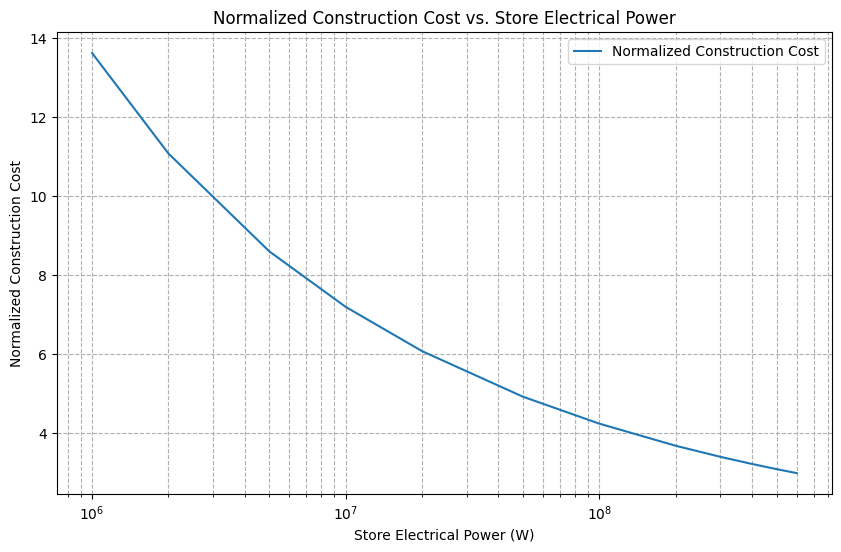

In [3]:
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 
parameters["deltaTmin_SSHX"] = parameters["min_temperature_exchange"]+5   #固-固换热器最小温差
parameters["deltaTmin_SGHX"] = parameters["min_temperature_exchange"]   #固-气换热器最小温差
parameters["industrial_waste_heat_t"] =300 #℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20   #环境温度
parameters["p_amb"] = 101325   #环境压力

parameters["p_bray_L"] = 7.5e6
parameters["Store_electrical_power"] = 50e6
parameters["p_water_supply_in"] = 2e5 
parameters["water_pressure_drop_rate"] = 100 #100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  #氧化钙转化率
parameters["cao_purity"] = 0.98 #氢氧化钙含量
parameters["dehydrator_eff"] = 0.95   #脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3/100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95   #水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs={}
inputs["p_bray_H"] = 18716228#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12481150 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"]=440
inputs["T_X"] = 1

# 经济输入的基础值
economic_inputs_base = {
    "elec_price": 0,  # 元/千瓦时
    "elec_price_h": 1.2784,
    "hot_price_h": 0.1542,
    "operation_hours": 2560,  # hours
    "discount_ratio": 6/100,  # 8%
    "operational_years": 60,
    "operation_labour_cost_indictor": 0.025/2*(2/3)/2,  # 劳动力比例
    "maintain_cost_indictor": 0.025/2/2  # 维护比例
}
store_elec_power_values = [1e6, 2e6, 5e6, 10e6, 20e6, 50e6, 100e6, 200e6, 300e6, 400e6, 500e6, 600e6]
 
# 创建一个列表来存储计算结果
normalized_cost_values = []
 
# 循环遍历每个 Store_electrical_power 值
for sep in store_elec_power_values:
    parameters["Store_electrical_power"] = sep
    
    # 复制经济输入并更新 operation_hours（如果需要的话，这里保持为原始值）
    economic_inputs = economic_inputs_base.copy()
    # 注意：如果 operation_hours 在你的 Cost_Estimator 或 solve 方法中有影响，确保它设置正确
    
    # 计算成本（这里假设 Cost_Estimator 和 solve 方法已经正确定义）
    cost = Cost_Estimator(parameters)
    results = cost.solve(inputs, economic_inputs)
    
    # 计算归一化的成本（即 total as-spent 除以 10 和 Store_electrical_power）
    normalized_cost = results["construction"]["total as-spent"] / 10 / parameters["Store_electrical_power"]
    
    # 将归一化的成本添加到列表中
    normalized_cost_values.append(normalized_cost)
 
# 绘制 Store_electrical_power 与归一化成本的变化趋势
plt.figure(figsize=(10, 6))
plt.plot(store_elec_power_values, normalized_cost_values, label='Normalized Construction Cost')
plt.xscale('log')  # 使用对数刻度来更好地显示大范围的数据
plt.xlabel('Store Electrical Power (W)')
plt.ylabel('Normalized Construction Cost')
plt.title('Normalized Construction Cost vs. Store Electrical Power')
plt.legend()
plt.grid(True, which="both", ls="--")  # 添加网格线以更好地阅读图表
plt.show()

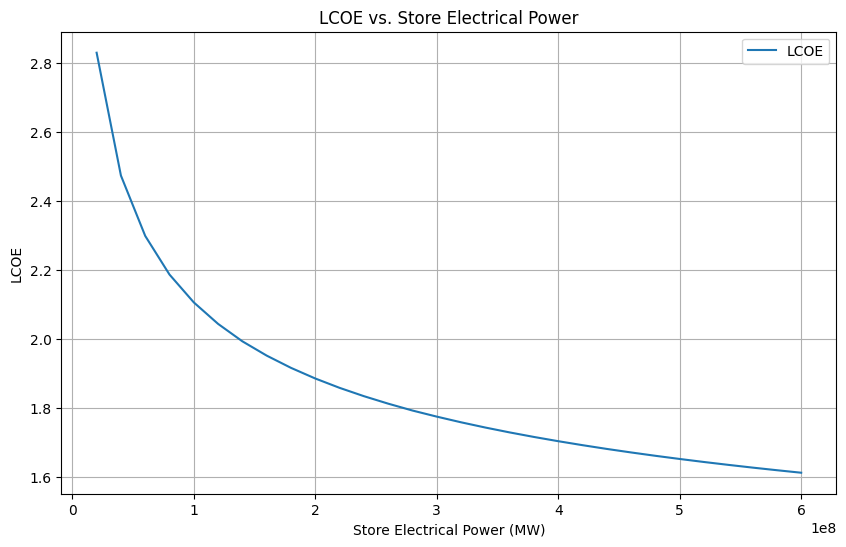

In [4]:
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["industrial_waste_heat_t"] =300 #℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20   #环境温度
parameters["p_amb"] = 101325   #环境压力

parameters["p_bray_L"] = 7.5e6
parameters["Store_electrical_power"] = 50e6  # 机组容量
parameters["p_water_supply_in"] = 2e5 
parameters["water_pressure_drop_rate"] = 100 #100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  #氧化钙转化率
parameters["cao_purity"] = 0.98 #氢氧化钙含量
parameters["dehydrator_eff"] = 0.95   #脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3/100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95   #水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"]=440
inputs["T_X"] = 1


economic_inputs={}
#economic_inputs["limestone_price"]=70
#economic_inputs["calciner_cost_factor"]=1
economic_inputs["elec_price"]=0.3 #元/千瓦时  ##S6
economic_inputs["hot_price_h"] = 0.1542 #每千瓦时0.1542元，42.84元/吉焦
economic_inputs["elec_price_h"] = 1.2784
economic_inputs["operation_hours"]=2560 # hours  ### S9
economic_inputs["discount_ratio"]=6/100 #8%
economic_inputs["operational_years"]=60
economic_inputs["operation_labour_cost_indictor"]=0.025/2*(2/3)/2 #劳动力比例
#年运行时间为一般机组的一半,天运行时间为一般机组的2/3，投资成本为一般机组的两倍以上
economic_inputs["maintain_cost_indictor"]=0.025/2/2 #维护比例 0.025,
#年运行时间为一般机组的一半，投资成本为一般机组的两倍以上故修正


store_power_values = [i * 20e6 for i in range(1, 31)]  # 从 1e6 到 600e6
LCOE_values = []
 
# 计算不同 Store_electrical_power 值下的 LCOE
for store_power in store_power_values:
    parameters["Store_electrical_power"] = store_power
    cost = Cost_Estimator(parameters)
    results = cost.solve(inputs, economic_inputs)
    LCOE_values.append(results["LCOE"])
 
# 绘制图像
plt.figure(figsize=(10, 6))
plt.plot(store_power_values, LCOE_values, label='LCOE')
plt.xlabel('Store Electrical Power (MW)')
plt.ylabel('LCOE')
plt.title('LCOE vs. Store Electrical Power')
plt.legend()
plt.grid(True)
plt.show()

findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Fon

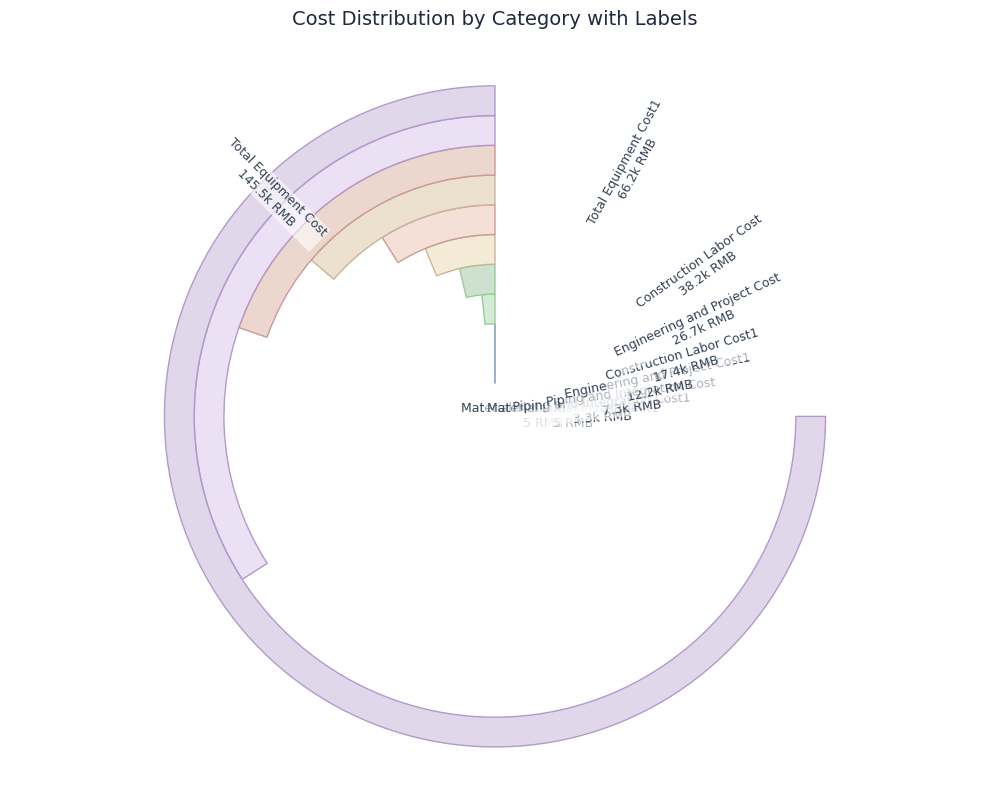

findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Fon

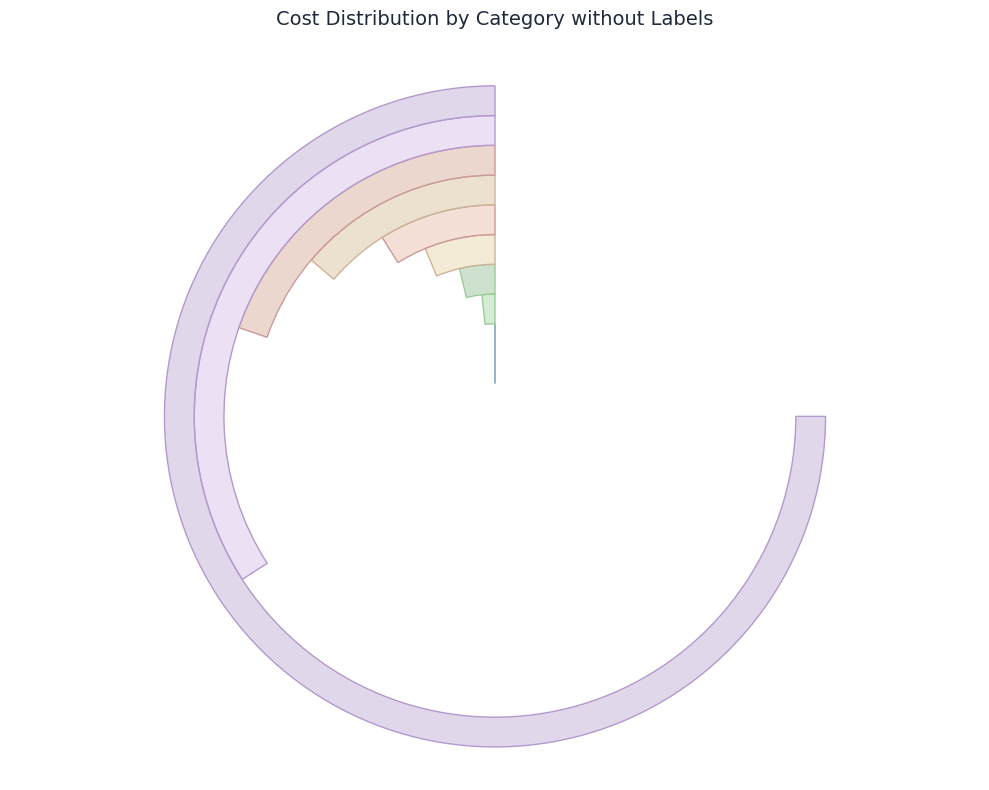

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Wedge
from matplotlib.colors import LinearSegmentedColormap

# 设置中文字体支持
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC", "sans-serif"]
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 数据
labels = ['Material Initial Investment1','Material Initial Investment', 'Piping and Integration Cost1','Piping and Integration Cost', 
          'Engineering and Project Cost1','Engineering and Project Cost', 'Construction Labor Cost1','Construction Labor Cost', 'Total Equipment Cost1','Total Equipment Cost']
#values = [5, 7276, 26739, 38199, 145521]
values = [5,5, 3309,7276, 12164,26739, 17377,38199, 66198,145521]
colors = [
    (0.8, 0.85, 0.9, 0.8),
    (0.76, 0.8075, 0.855, 0.8),  # 加深的浅蓝色
    (0.8, 0.9, 0.8, 0.8),
    (0.76, 0.855, 0.76, 0.8),    # 加深的浅绿色
    (0.95, 0.9, 0.8, 0.8),
    (0.9025, 0.855, 0.76, 0.8),  # 加深的浅黄色
    (0.95, 0.85, 0.8, 0.8),
    (0.9025, 0.8075, 0.76, 0.8), # 加深的浅红色
    (0.9, 0.85, 0.95, 0.8),
    (0.855, 0.8075, 0.9025, 0.8) # 加深的浅紫色
]
edgecolors = [
    (0.6, 0.7, 0.8, 1.0),
    (0.6, 0.7, 0.8, 1.0),
    (0.6, 0.8, 0.6, 1.0),
    (0.6, 0.8, 0.6, 1.0),
    (0.8, 0.7, 0.6, 1.0),
    (0.8, 0.7, 0.6, 1.0),
    (0.8, 0.6, 0.6, 1.0),
    (0.8, 0.6, 0.6, 1.0),
    (0.7, 0.6, 0.8, 1.0),
    (0.7, 0.6, 0.8, 1.0)
]

# 创建一个函数来绘制环状条形图
def plot_ring_bar(labels, values, colors, edgecolors, title, show_labels=True, figsize=(10, 8)):
    """
    绘制环状条形图
    
    参数:
    labels: 标签列表
    values: 数值列表
    colors: 颜色列表
    edgecolors: 边框颜色列表
    title: 图表标题
    show_labels: 是否显示标签
    figsize: 图表大小
    """
    # 创建画布
    fig, ax = plt.subplots(figsize=figsize)
    
    # 确保数据按值排序
    sorted_data = sorted(zip(values, labels, colors, edgecolors), reverse=False)
    values_sorted, labels_sorted, colors_sorted, edgecolors_sorted = zip(*sorted_data)
    
    # 计算最大半径和内圆半径
    max_radius = 1.0
    inner_radius = 0.1  # 减小内圆半径，使条形更明显
    
    # 计算每个条形的厚度
    n_bars = len(values_sorted)
    bar_thickness = (max_radius - inner_radius) / n_bars
     
    # 计算每个条形的角度范围（最大的条形占据270度）
    max_angle = 270  # 约3/4圆周
    
    # 绘制每个条形作为圆环的一段
    for i, (value, label, color, edgecolor) in enumerate(zip(values_sorted, labels_sorted, colors_sorted, edgecolors_sorted)):
        # 计算条形的内半径和外半径
        bar_inner_radius = inner_radius + i * bar_thickness
        bar_outer_radius = bar_inner_radius + bar_thickness
        
        # 计算条形的角度（基于最大值的比例）
        max_value = max(values_sorted)
        angle = (value / max_value) * max_angle
        
        # 绘制条形（所有条形从90度开始，即垂直向上）
        bar = Wedge((0, 0), bar_outer_radius, 90, 90 + angle, 
                width=bar_thickness, facecolor=color, 
                edgecolor=edgecolor, linewidth=1.0)
        ax.add_patch(bar)
        
        # 如果需要显示标签，计算标签位置并添加
        if show_labels:
            # 计算标签的角度位置（条形的中间）
            label_angle = angle / 2
            
            # 将角度转换为弧度
            label_rad = np.radians(label_angle)
            
            # 计算标签的位置（在条形的中间半径处）
            label_distance = (bar_inner_radius + bar_outer_radius) / 2
            label_x = label_distance * np.cos(label_rad)
            label_y = label_distance * np.sin(label_rad)
            
            # 格式化数值显示
            if value >= 1000:
                value_str = f"{value/1000:.1f}k"
            else:
                value_str = f"{value}"
            
            # 计算文本对齐方式
            ha = 'center'
            va = 'center'
            
            # 旋转文本使其与圆弧对齐
            rotation = label_angle if label_angle <= 90 or label_angle >= 270 else label_angle - 180
            
            # 添加标签文本
            ax.text(label_x, label_y, f"{label}\n{value_str} RMB", 
                    ha=ha, va=va, rotation=rotation, fontsize=9, color='#334155',
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1.0))
        
    # 设置坐标轴范围
    ax.set_xlim(-max_radius * 1.2, max_radius * 1.2)
    ax.set_ylim(-max_radius * 1.2, max_radius * 1.2)
    
    # 隐藏坐标轴
    ax.axis('equal')
    ax.axis('off')
    
    # 添加标题
    plt.title(title, fontsize=14, pad=20, color='#1e293b')
    
    return fig, ax

# 绘制带标注的图表
fig1, ax1 = plot_ring_bar(labels, values, colors, edgecolors, "Cost Distribution by Category with Labels", show_labels=True)
plt.tight_layout()

# 绘制不带标注的图表
fig2, ax2 = plot_ring_bar(labels, values, colors, edgecolors, "Cost Distribution by Category without Labels", show_labels=False)
plt.tight_layout()

# 显示图表
plt.show()    

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

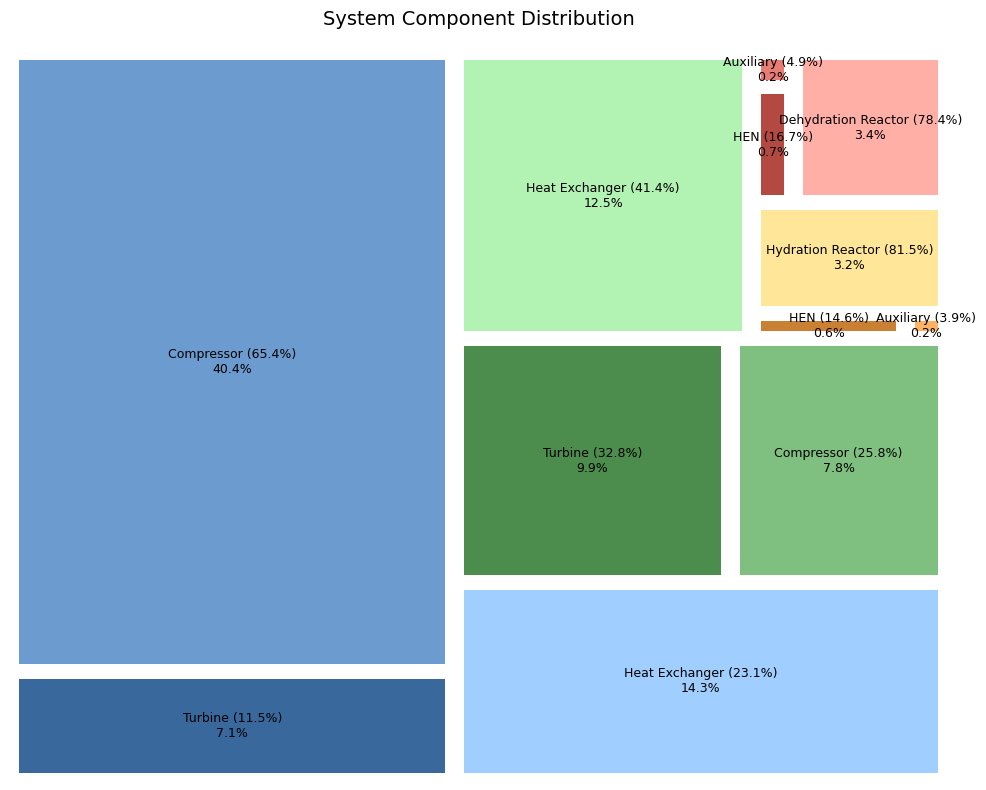

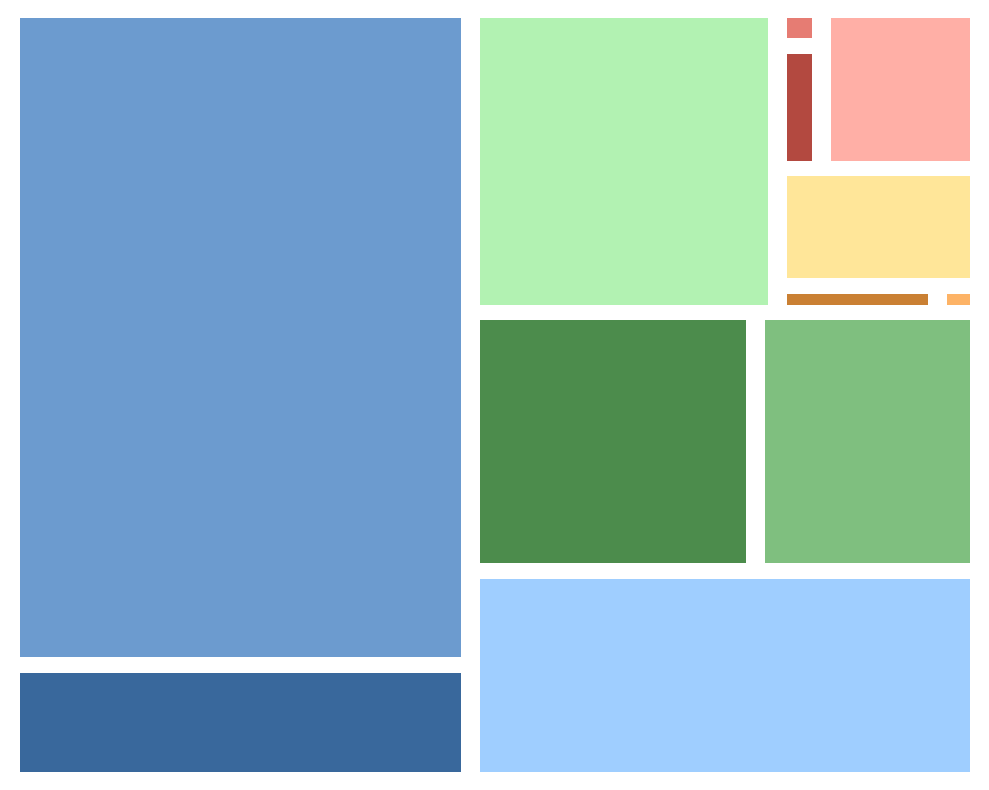

In [21]:
import matplotlib.pyplot as plt
import squarify
import matplotlib.colors as mcolors
import numpy as np

# 设置全局字体
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10

# 数据定义
data = {
    'BHP (61.7%)': {
        'Turbine (11.5%)': 11.5,
        'Compressor (65.4%)': 65.4,
        'Heat Exchanger (23.1%)': 23.1
    },
    'BP (30.1%)': {
        'Turbine (32.8%)': 32.8,
        'Compressor (25.8%)': 25.8,
        'Heat Exchanger (41.4%)': 41.4
    },
    'Hydration Reactor & HEN (3.9%)': {
        'HEN (14.6%)': 14.6,
        'Auxiliary (3.9%)': 3.9,
        'Hydration Reactor (81.5%)': 81.5
    },
    'Dehydration Reactor & HEN (4.3%)': {
        'HEN (16.7%)': 16.7,
        'Auxiliary (4.9%)': 4.9,
        'Dehydration Reactor (78.4%)': 78.4
    }
}

# 计算全局占比
sizes = []
labels = []
categories = []
parent_colors = []

# 为每个父类别分配基础色
base_colors = [
    '#6c9bcf',  # BHP: 浅蓝
    '#7fbf7f',  # BP: 浅绿
    '#fdb366',  # Hydration: 浅橙
    '#e67c73'   # Dehydration: 浅红
]

for i, (parent, children) in enumerate(data.items()):
    parent_percent = float(parent.split('(')[1].split('%')[0])
    for child, percent in children.items():
        # 计算全局占比 = 父类占比 × 子类相对占比
        global_percent = parent_percent * percent / 100
        sizes.append(global_percent)
        labels.append(f"{child}\n{global_percent:.1f}%")
        categories.append(parent)
        
        # 为子类生成颜色 (基于父类颜色微调)
        base_rgb = mcolors.hex2color(base_colors[i])
        adjust_factor = 0.2 * (list(children.keys()).index(child) - 1)  # 根据子类顺序调整
        child_color = np.clip([c + adjust_factor for c in base_rgb], 0, 1)
        parent_colors.append(mcolors.rgb2hex(child_color))

# 绘制带标注的树状图
plt.figure(figsize=(10, 8))
squarify.plot(sizes=sizes, label=labels, color=parent_colors, 
              text_kwargs={'fontsize':9, 'color':'black'}, pad=True)
plt.axis('off')
plt.title('System Component Distribution', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 绘制不带标注的树状图
plt.figure(figsize=(10, 8))
squarify.plot(sizes=sizes, color=parent_colors, pad=True)
plt.axis('off')
plt.tight_layout()
plt.show()